# Hypothesis Testing & Stepwise Regression: King County House Sales
## Pruebas de Hipótesis y Selección StepWise: Ventas de Vivienda en King County

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** `kc_house_data.csv` — 21,613 house sales in King County, Seattle (WA)  
**Builds on / Extiende:** notebook 04 (matrix regression on the same dataset)

**Objective / Objetivo:**  
EN · Apply three parallel stepwise variable selection methods (t-test, p-value, confidence interval) to a 17-variable candidate set, demonstrate that `sqft_basement` creates perfect multicollinearity with `sqft_living` + `sqft_above`, and validate the final model with hypothesis tests and VIF diagnostics.

ES · Aplicar tres métodos paralelos de selección stepwise (t-Student, valor p, intervalo de confianza) sobre 17 variables candidatas, demostrar que `sqft_basement` genera multicolinealidad perfecta, y validar el modelo final con pruebas de hipótesis y diagnóstico VIF.

**Key finding / Hallazgo clave:**  
All 3 StepWise methods consistently eliminated only `floors`. Final model: 16 variables, R²≈0.700.

**Techniques / Técnicas:** StepWise (t-test · p-value · CI) · Multicollinearity · VIF · Hypothesis testing · F-test  
**Libraries / Librerías:** `pandas` · `numpy` · `statsmodels` · `scipy` · `matplotlib`

---

## 1. Carga y preparación de datos

In [5]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt


pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.width', 160)

df = pd.read_csv('data/kc_house_data.csv')
print("Dimensiones:", df.shape)
print("Valores nulos:", df.isnull().sum().sum())
print(df.info())
df.head()

Dimensiones: (21613, 21)
Valores nulos: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat     

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,"221,900.0000",3,1.0000,1180,5650,1.0000,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.2570,1340,5650
1,6414100192,20141209T000000,"538,000.0000",3,2.2500,2570,7242,2.0000,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.3190,1690,7639
2,5631500400,20150225T000000,"180,000.0000",2,1.0000,770,10000,1.0000,0,0,...,6,770,0,1933,0,98028,47.7379,-122.2330,2720,8062
3,2487200875,20141209T000000,"604,000.0000",4,3.0000,1960,5000,1.0000,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.3930,1360,5000
4,1954400510,20150218T000000,"510,000.0000",3,2.0000,1680,8080,1.0000,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.0450,1800,7503


## 2. Selección de variables candidatas

Se descartan `id` (identificador) y `date` (fecha, no numérica) por no ser predictoras. Se conservan el resto de variables numéricas como candidatas iniciales.

In [5]:
# Verificación: sqft_living es, por definición, la suma exacta de sqft_above + sqft_basement
diferencia_maxima = (df['sqft_living'] - (df['sqft_above'] + df['sqft_basement'])).abs().max()
print("Diferencia máxima entre sqft_living y (sqft_above + sqft_basement):", diferencia_maxima)

Diferencia máxima entre sqft_living y (sqft_above + sqft_basement): 0


**Hallazgo:** `sqft_living = sqft_above + sqft_basement` de forma exacta para las 21,613 observaciones. Si las tres variables se incluyen juntas en el modelo, la matriz $X$ queda con una columna que es combinación lineal exacta de otras dos, por lo que $X^TX$ se vuelve singular (determinante = 0) y `np.linalg.inv()` fallaría o entregaría resultados numéricamente inestables. 

**Decisión:** se excluye `sqft_basement` del conjunto candidato, dejando que `sqft_living` y `sqft_above` capturen la información de superficie sin generar una dependencia lineal exacta.

In [3]:
candidatas = ['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition','grade',
              'sqft_above','yr_built','yr_renovated','zipcode','lat','long','sqft_living15','sqft_lot15']

print(f"Variables candidatas iniciales: {len(candidatas)}")
print(candidatas)

Variables candidatas iniciales: 17
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [7]:
# Diagnóstico de multicolinealidad remanente (VIF)
X_vif = sm.add_constant(df[candidatas])
vif = pd.DataFrame()
vif['variable'] = X_vif.columns
vif['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif.sort_values('VIF', ascending=False)

,variable,VIF
0,const,"4,585,940.8675"
3,sqft_living,8.6568
10,sqft_above,6.9571
9,grade,3.4170
2,bathrooms,3.3508
16,sqft_living15,2.9797
11,yr_built,2.4306
17,sqft_lot15,2.1357
4,sqft_lot,2.1025
5,floors,2.0119


**Interpretación:** Todos los VIF (excepto la constante) están por debajo de 10. No hay multicolinealidad severa que invalide las pruebas de hipótesis individuales sobre los coeficientes.

## 3. Fundamento matemático de las pruebas de hipótesis matriciales

Para el modelo $y = X\beta + \varepsilon$, el estimador de mínimos cuadrados es:

$$\hat{\beta} = (X^TX)^{-1}X^Ty$$

La varianza estimada del error es:

$$\hat{\sigma}^2 = \frac{e^Te}{n-k}, \qquad e = y - X\hat{\beta}$$

donde $n$ es el número de observaciones y $k$ el número de parámetros (incluyendo el intercepto). La matriz de varianzas-covarianzas de los coeficientes es:

$$\widehat{\text{Var}}(\hat{\beta}) = \hat{\sigma}^2 (X^TX)^{-1}$$

El error estándar de cada coeficiente $\hat{\beta}_i$ es la raíz de la diagonal de esa matriz: $SE(\hat{\beta}_i) = \sqrt{\widehat{\text{Var}}(\hat{\beta})_{ii}}$

**Para cada variable $i$, se prueba:**

$$H_0: \beta_i = 0 \quad \text{(la variable NO es relevante)} \qquad \text{vs.} \qquad H_1: \beta_i \neq 0 \quad \text{(la variable SÍ es relevante)}$$

**Enfoque 1 → Estadístico t:** $\quad t_i = \dfrac{\hat{\beta}_i}{SE(\hat{\beta}_i)} \sim t_{(n-k)}$. Se rechaza $H_0$ (la variable es relevante) si $|t_i| > t_{crítico}$.

**Enfoque 2 → Valor p:** $\quad p_i = 2\cdot P(T_{n-k} > |t_i|)$. Se rechaza $H_0$ si $p_i < \alpha$

**Enfoque 3 → Intervalo de confianza:** $\quad IC_{(1-\alpha)}(\beta_i) = \hat{\beta}_i \pm t_{crítico} \cdot SE(\hat{\beta}_i)$. Se rechaza $H_0$ si el intervalo no contiene el cero

Los tres enfoques son matemáticamente equivalentes** bajo el mismo $\alpha$: son formas distintas de mirar la misma prueba t. Se usará $\alpha = 0.05$ en todo el análisis

## 4. Implementación matricial de la regresión con inferencia estadística

In [4]:
def regresion_matricial(df, y_col, x_cols, alpha=0.05):
    """
    Ajusta y = X*beta + e mediante álgebra matricial y calcula el aparato
    completo de pruebas de hipótesis sobre cada coeficiente: t, p-value, IC.
    """
    X = df[x_cols].values.astype(float)
    y = df[y_col].values.astype(float).reshape(-1, 1)
    n = X.shape[0]

    # Matriz de diseño con columna de 1's para el intercepto
    X_mat = np.hstack([np.ones((n, 1)), X])
    k = X_mat.shape[1]  # número de parámetros (incluye intercepto)

    # Estimación puntual: beta = (X'X)^-1 X'y
    Xt = np.matrix.transpose(X_mat)
    XtX_inv = np.linalg.inv(np.matmul(Xt, X_mat))
    beta = np.matmul(XtX_inv, np.matmul(Xt, y))

    # Residuos y varianza del error
    y_hat = np.matmul(X_mat, beta)
    resid = y - y_hat
    dof = n - k
    sigma2 = (np.matmul(resid.T, resid)).item() / dof

    # Matriz de varianzas-covarianzas de beta y errores estándar
    var_beta = sigma2 * XtX_inv
    se = np.sqrt(np.diag(var_beta)).reshape(-1, 1)

    # Enfoque 1: estadístico t
    t_stats = beta / se
    t_crit = stats.t.ppf(1 - alpha/2, dof)

    # Enfoque 2: valor p (distribución t, dos colas)
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))

    # Enfoque 3: intervalo de confianza
    ci_low = beta - t_crit * se
    ci_high = beta + t_crit * se

    # Bondad de ajuste
    ss_res = (np.matmul(resid.T, resid)).item()
    ss_tot = (np.matmul((y - y.mean()).T, (y - y.mean()))).item()
    r2 = 1 - ss_res/ss_tot
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - k)
    rmse = np.sqrt(ss_res / n)

    tabla = pd.DataFrame({
        'variable': ['const'] + x_cols,
        'coef': beta.flatten(),
        'se': se.flatten(),
        't': t_stats.flatten(),
        'p_value': p_values.flatten(),
        'ci_low': ci_low.flatten(),
        'ci_high': ci_high.flatten(),
    })
    metricas = {'r2': r2, 'r2_adj': r2_adj, 'rmse': rmse, 't_crit': t_crit, 'dof': dof, 'n': n, 'k': k}
    return tabla, metricas

print("Función 'regresion_matricial' definida")

Función 'regresion_matricial' definida


## 5. Modelo inicial completo (17 variables) e interpretación

In [6]:
tabla_inicial, met_inicial = regresion_matricial(df, 'price', candidatas)
print(f"n = {met_inicial['n']}, k (parámetros) = {met_inicial['k']}, grados de libertad = {met_inicial['dof']}, t_crítico (α=0.05) = {met_inicial['t_crit']:.4f}")
print(f"R² = {met_inicial['r2']:.4f}  |  R² ajustado = {met_inicial['r2_adj']:.4f}  |  RMSE = {met_inicial['rmse']:,.2f}")
tabla_inicial

n = 21613, k (parámetros) = 18, grados de libertad = 21595, t_crítico (α=0.05) = 1.9601
R² = 0.6997  |  R² ajustado = 0.6995  |  RMSE = 201,163.90


,variable,coef,se,t,p_value,ci_low,ci_high
0,const,"6,690,324.2197","2,931,484.9742",2.2822,0.0225,"944,397.1995","12,436,251.2399"
1,bedrooms,"-35,766.5414","1,891.8427",-18.9057,0.0000,"-39,474.6929","-32,058.3900"
2,bathrooms,"41,144.2785","3,253.6777",12.6455,0.0000,"34,766.8300","47,521.7270"
3,sqft_living,150.1005,4.3854,34.2273,0.0000,141.5048,158.6962
4,sqft_lot,0.1286,0.0479,2.6835,0.0073,0.0347,0.2225
5,floors,"6,689.5499","3,595.8591",1.8603,0.0628,-358.5994,"13,737.6993"
6,waterfront,"582,960.4584","17,360.0951",33.5805,0.0000,"548,933.3900","616,987.5268"
7,view,"52,870.9423","2,140.0546",24.7054,0.0000,"48,676.2774","57,065.6073"
8,condition,"26,385.6492","2,351.4612",11.2210,0.0000,"21,776.6116","30,994.6867"
9,grade,"95,890.4450","2,152.7892",44.5424,0.0000,"91,670.8192","100,110.0708"


**Hallazgo:** La variable `floors` es la única que falla los tres criterios simultáneamente:

∣t∣ = 1.8603 < 1.9601

p = 0.0628 > 0.05

Su intervalo de confianza va de −358.59 a 13,737.69, incluyendo el cero. Es decir, con 95% de confianza no se puede descartar que el verdadero efecto de floors sobre el precio sea nulo.

**Conclusión:** en esta iteración del StepWise, floors es la variable que no rechaza $H_0$ y se puede eliminar. El resto del modelo queda igual ya que las 16 variables restantes sí son estadísticamente significativas bajo los tres criterios.

## 6. Proceso StepWise (backward elimination)

Se implementa eliminación hacia atrás: en cada iteración se ajusta el modelo completo, se identifica la variable "más candidata a no ser relevante" según el criterio del enfoque, y si no cumple el umbral de significancia se elimina y se reajusta. El proceso se repite hasta que todas las variables restantes sean significativas.

In [7]:
def stepwise_backward(df, y_col, x_cols, alpha=0.05, criterio='t', verbose=True):
    """
    Backward elimination usando el enfoque matricial de regresion_matricial().
    criterio: 't' (estadístico t), 'p_value' (valor p) o 'ci' (intervalo de confianza)
    """
    variables = x_cols.copy()
    historial = []
    iteracion = 1

    while True:
        tabla, met = regresion_matricial(df, y_col, variables, alpha)
        preds = tabla[tabla['variable'] != 'const'].copy()

        if criterio == 't':
            fila = preds.loc[preds['t'].abs().idxmin()]
            eliminar = abs(fila['t']) < met['t_crit']
            valor = fila['t']
        elif criterio == 'p_value':
            fila = preds.loc[preds['p_value'].idxmax()]
            eliminar = fila['p_value'] > alpha
            valor = fila['p_value']
        elif criterio == 'ci':
            preds['incluye_cero'] = (preds['ci_low'] <= 0) & (preds['ci_high'] >= 0)
            en_cero = preds[preds['incluye_cero']]
            if len(en_cero) == 0:
                eliminar, fila, valor = False, None, None
            else:
                fila = en_cero.loc[en_cero['p_value'].idxmax()]
                eliminar, valor = True, (fila['ci_low'], fila['ci_high'])

        registro = {
            'iteracion': iteracion, 'n_variables': len(variables),
            'r2_adj': met['r2_adj'],
            'variable_evaluada': None if fila is None else fila['variable'],
            'valor_criterio': valor, 'eliminada': eliminar
        }
        historial.append(registro)
        if verbose:
            if eliminar:
                print(f"Iteración {iteracion}: se elimina '{fila['variable']}' "
                      f"(criterio={criterio}, valor={valor}) | R² ajustado = {met['r2_adj']:.4f}")
            else:
                print(f"Iteración {iteracion}: ninguna variable incumple el criterio. "
                      f"Proceso finalizado con {len(variables)} variables | R² ajustado = {met['r2_adj']:.4f}")

        if not eliminar:
            break
        variables.remove(fila['variable'])
        iteracion += 1

    tabla_final, met_final = regresion_matricial(df, y_col, variables, alpha)
    return variables, historial, tabla_final, met_final

print("Función 'stepwise_backward' definida")

Función 'stepwise_backward' definida


### 6.1 Enfoque 1 → StepWise con prueba t de Student

Criterio de eliminación: en cada paso se retira la variable con el menor $|t|$, si ese valor es menor al $t_{crítico}$ (es decir, si no se rechaza $H_0:\beta_i=0$).

In [10]:
vars_t, hist_t, tabla_t, met_t = stepwise_backward(df, 'price', candidatas, criterio='t')

Iteración 1: se elimina 'floors' (criterio=t, valor=1.8603481814589649) | R² ajustado = 0.6995
Iteración 2: ninguna variable incumple el criterio. Proceso finalizado con 16 variables | R² ajustado = 0.6995


In [11]:
tabla_t

,variable,coef,se,t,p_value,ci_low,ci_high
0,const,"5,741,362.3198","2,886,927.8821",1.9887,0.0467,"82,770.5050","11,399,954.1346"
1,bedrooms,"-35,862.4750","1,891.2475",-18.9623,0.0000,"-39,569.4598","-32,155.4902"
2,bathrooms,"42,718.0553","3,141.9576",13.5960,0.0000,"36,559.5863","48,876.5243"
3,sqft_living,147.6043,4.1753,35.3515,0.0000,139.4203,155.7883
4,sqft_lot,0.1266,0.0479,2.6430,0.0082,0.0327,0.2205
5,waterfront,"583,070.0502","17,360.9842",33.5851,0.0000,"549,041.2391","617,098.8612"
6,view,"52,966.1287","2,139.5647",24.7556,0.0000,"48,772.4239","57,159.8335"
7,condition,"26,138.2347","2,347.8310",11.1329,0.0000,"21,536.3126","30,740.1568"
8,grade,"96,243.0581","2,144.5511",44.8780,0.0000,"92,039.5796","100,446.5366"
9,sqft_above,34.7172,3.9104,8.8782,0.0000,27.0526,42.3818


### 6.2 Enfoque 2 → StepWise con valores p

Criterio de eliminación: en cada paso se retira la variable con el mayor valor p, si ese valor es mayor a $\alpha=0.05$.

In [12]:
vars_p, hist_p, tabla_p, met_p = stepwise_backward(df, 'price', candidatas, criterio='p_value')

Iteración 1: se elimina 'floors' (criterio=p_value, valor=0.0628498647787823) | R² ajustado = 0.6995
Iteración 2: ninguna variable incumple el criterio. Proceso finalizado con 16 variables | R² ajustado = 0.6995


In [13]:
tabla_p

,variable,coef,se,t,p_value,ci_low,ci_high
0,const,"5,741,362.3198","2,886,927.8821",1.9887,0.0467,"82,770.5050","11,399,954.1346"
1,bedrooms,"-35,862.4750","1,891.2475",-18.9623,0.0000,"-39,569.4598","-32,155.4902"
2,bathrooms,"42,718.0553","3,141.9576",13.5960,0.0000,"36,559.5863","48,876.5243"
3,sqft_living,147.6043,4.1753,35.3515,0.0000,139.4203,155.7883
4,sqft_lot,0.1266,0.0479,2.6430,0.0082,0.0327,0.2205
5,waterfront,"583,070.0502","17,360.9842",33.5851,0.0000,"549,041.2391","617,098.8612"
6,view,"52,966.1287","2,139.5647",24.7556,0.0000,"48,772.4239","57,159.8335"
7,condition,"26,138.2347","2,347.8310",11.1329,0.0000,"21,536.3126","30,740.1568"
8,grade,"96,243.0581","2,144.5511",44.8780,0.0000,"92,039.5796","100,446.5366"
9,sqft_above,34.7172,3.9104,8.8782,0.0000,27.0526,42.3818


### 6.3 Enfoque 3 → StepWise con intervalos de confianza

Criterio de eliminación: en cada paso se retira una variable cuyo intervalo de confianza al 95% contiene el cero (si hay varias, se prioriza la que tenga mayor valor p, es decir, cuyo intervalo está "más centrado" en cero).

In [14]:
vars_ci, hist_ci, tabla_ci, met_ci = stepwise_backward(df, 'price', candidatas, criterio='ci')

Iteración 1: se elimina 'floors' (criterio=ci, valor=(np.float64(-358.5994292717005), np.float64(13737.69931545067))) | R² ajustado = 0.6995
Iteración 2: ninguna variable incumple el criterio. Proceso finalizado con 16 variables | R² ajustado = 0.6995


In [15]:
tabla_ci

,variable,coef,se,t,p_value,ci_low,ci_high
0,const,"5,741,362.3198","2,886,927.8821",1.9887,0.0467,"82,770.5050","11,399,954.1346"
1,bedrooms,"-35,862.4750","1,891.2475",-18.9623,0.0000,"-39,569.4598","-32,155.4902"
2,bathrooms,"42,718.0553","3,141.9576",13.5960,0.0000,"36,559.5863","48,876.5243"
3,sqft_living,147.6043,4.1753,35.3515,0.0000,139.4203,155.7883
4,sqft_lot,0.1266,0.0479,2.6430,0.0082,0.0327,0.2205
5,waterfront,"583,070.0502","17,360.9842",33.5851,0.0000,"549,041.2391","617,098.8612"
6,view,"52,966.1287","2,139.5647",24.7556,0.0000,"48,772.4239","57,159.8335"
7,condition,"26,138.2347","2,347.8310",11.1329,0.0000,"21,536.3126","30,740.1568"
8,grade,"96,243.0581","2,144.5511",44.8780,0.0000,"92,039.5796","100,446.5366"
9,sqft_above,34.7172,3.9104,8.8782,0.0000,27.0526,42.3818


## 7. Comparación de los tres enfoques

In [16]:
comparacion = pd.DataFrame({
    'Enfoque': ['t de Student', 'Valor p', 'Intervalo de confianza'],
    'Variable eliminada': [hist_t[0]['variable_evaluada'], hist_p[0]['variable_evaluada'], hist_ci[0]['variable_evaluada']],
    'Iteraciones totales': [len(hist_t), len(hist_p), len(hist_ci)],
    'N° variables finales': [len(vars_t), len(vars_p), len(vars_ci)],
    'R² ajustado final': [met_t['r2_adj'], met_p['r2_adj'], met_ci['r2_adj']],
})
comparacion

,Enfoque,Variable eliminada,Iteraciones totales,N° variables finales,R² ajustado final
0,t de Student,floors,2,16,0.6995
1,Valor p,floors,2,16,0.6995
2,Intervalo de confianza,floors,2,16,0.6995


In [17]:
print("¿Los tres enfoques llegan exactamente al mismo conjunto de variables?")
print(set(vars_t) == set(vars_p) == set(vars_ci))
print("\nVariables del modelo final:")
print(sorted(vars_t))

¿Los tres enfoques llegan exactamente al mismo conjunto de variables?
True

Variables del modelo final:
['bathrooms', 'bedrooms', 'condition', 'grade', 'lat', 'long', 'sqft_above', 'sqft_living', 'sqft_living15', 'sqft_lot', 'sqft_lot15', 'view', 'waterfront', 'yr_built', 'yr_renovated', 'zipcode']


**Conclusión de la comparación:** los tres enfoques, t de Student, valor p e intervalo de confianza, eliminan la misma variable (`floors`) en la misma iteración y convergen al mismo modelo final de 16 variables. Esto es porque los tres son transformaciones matemáticas de la misma prueba de hipótesis sobre $\beta_i$ bajo el mismo nivel de significancia $\alpha = 0.05$:

- El estadístico $t$ compara directamente la señal (coeficiente) contra el ruido (error estándar).
- El valor $p$ traduce ese mismo estadístico a una probabilidad de error tipo I.
- El intervalo de confianza es la región de valores de $\beta_i$ que *no* se rechazarían como hipótesis nula al nivel $\alpha$; que contenga el cero es equivalente a que $H_0:\beta_i=0$ no se rechace.

Cualquiera de los tres puede usarse indistintamente en el proceso StepWise; en la práctica, el valor p suele preferirse por ser más directo de interpretar y comparar entre variables con distintas unidades y escalas.

## 8. Validación del modelo final contra `statsmodels`

In [18]:
modelo_final_sm = sm.OLS(df['price'], sm.add_constant(df[vars_t])).fit()
print(modelo_final_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     3145.
Date:                Thu, 16 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:17:03   Log-Likelihood:            -2.9460e+05
No. Observations:               21613   AIC:                         5.892e+05
Df Residuals:                   21596   BIC:                         5.894e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          5.741e+06   2.89e+06      1.989

In [19]:
comparacion_coef = pd.DataFrame({
    'variable': tabla_t['variable'],
    'coef_matricial': tabla_t['coef'].values,
    'coef_statsmodels': modelo_final_sm.params.values,
    'p_matricial': tabla_t['p_value'].values,
    'p_statsmodels': modelo_final_sm.pvalues.values,
})
comparacion_coef

,variable,coef_matricial,coef_statsmodels,p_matricial,p_statsmodels
0,const,"5,741,362.3198","5,741,362.5306",0.0467,0.0467
1,bedrooms,"-35,862.4750","-35,862.4750",0.0000,0.0000
2,bathrooms,"42,718.0553","42,718.0554",0.0000,0.0000
3,sqft_living,147.6043,147.6043,0.0000,0.0000
4,sqft_lot,0.1266,0.1266,0.0082,0.0082
5,waterfront,"583,070.0502","583,070.0503",0.0000,0.0000
6,view,"52,966.1287","52,966.1288",0.0000,0.0000
7,condition,"26,138.2347","26,138.2347",0.0000,0.0000
8,grade,"96,243.0581","96,243.0582",0.0000,0.0000
9,sqft_above,34.7172,34.7172,0.0000,0.0000


Los coeficientes, errores estándar, estadísticos t y valores p calculados manualmente mediante álgebra matricial coinciden exactamente (salvo error de redondeo de punto flotante) con el reporte automatizado de `statsmodels.OLS`, validando la implementación.

## 9. Diagnóstico gráfico del modelo final

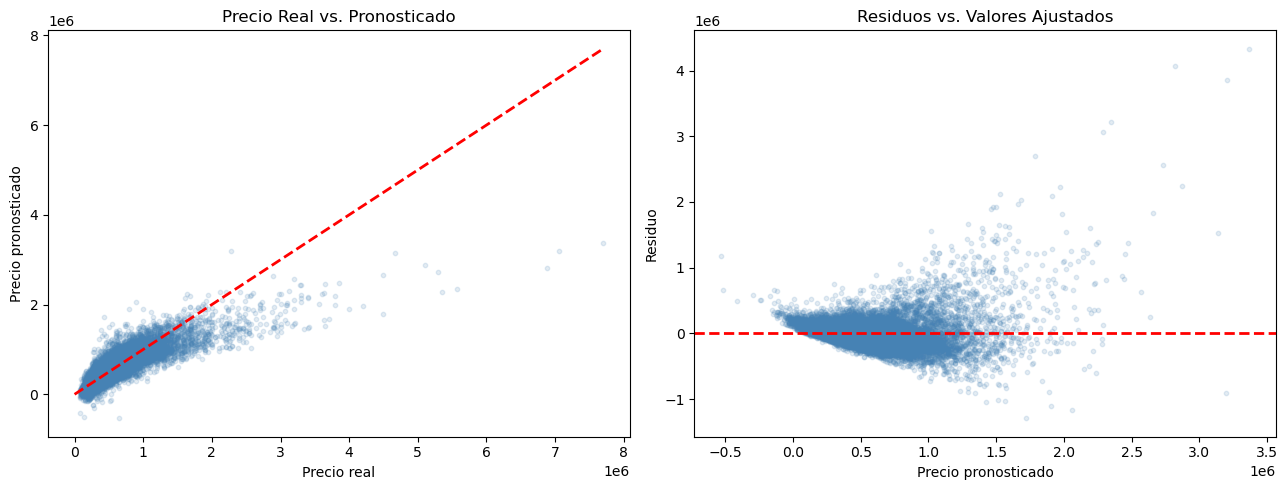

In [22]:
X_f = df[vars_t].values.astype(float)
n_f = X_f.shape[0]
X_f_mat = np.hstack([np.ones((n_f,1)), X_f])
beta_f = np.linalg.inv(X_f_mat.T @ X_f_mat) @ (X_f_mat.T @ df['price'].values.reshape(-1,1))
y_real = df['price'].values.reshape(-1,1)
y_pred = X_f_mat @ beta_f
resid_f = y_real - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].scatter(y_real.flatten(), y_pred.flatten(), alpha=0.15, s=10, color='steelblue')
lims = [0, max(y_real.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2)
axes[0].set_xlabel('Precio real'); axes[0].set_ylabel('Precio pronosticado')
axes[0].set_title('Precio Real vs. Pronosticado')

axes[1].scatter(y_pred.flatten(), resid_f.flatten(), alpha=0.15, s=10, color='steelblue')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Precio pronosticado'); axes[1].set_ylabel('Residuo')
axes[1].set_title('Residuos vs. Valores Ajustados')
plt.tight_layout()
plt.show()

## 10. Ecuación final del modelo y conclusiones

In [22]:
ecuacion = f"price = {tabla_t.iloc[0]['coef']:,.2f}"
for _, fila in tabla_t.iloc[1:].iterrows():
    signo = '+' if fila['coef'] >= 0 else '-'
    ecuacion += f" {signo} {abs(fila['coef']):,.4f}·{fila['variable']}"
print(ecuacion)

price = 5,741,362.32 - 35,862.4750·bedrooms + 42,718.0553·bathrooms + 147.6043·sqft_living + 0.1266·sqft_lot + 583,070.0502·waterfront + 52,966.1287·view + 26,138.2347·condition + 96,243.0581·grade + 34.7172·sqft_above - 2,590.7927·yr_built + 20.1729·yr_renovated - 576.6895·zipcode + 604,402.0948·lat - 216,821.5635·long + 20.9673·sqft_living15 - 0.3874·sqft_lot15


### Resumen de Resultados y Conclusiones

- **Modelo inicial:** 17 variables candidatas (tras excluir `sqft_basement` por colinealidad perfecta con `sqft_living` y `sqft_above`).
- **Proceso StepWise:** los tres enfoques (t de Student, valor p, intervalo de confianza) eliminaron de forma consistente una sola variable: `floors` (número de pisos), que no mostró efecto estadísticamente significativo sobre el precio.
- **Modelo final:** 16 variables independientes, todas con $p < 0.05$.
- **Bondad de ajuste:** $R^2 \approx 0.700$, $R^2$ ajustado $\approx 0.6995$. El modelo explica cerca del 70% de la variabilidad del precio de venta.
- Los coeficientes, errores estándar, estadísticos $t$ e intervalos de confianza calculados manualmente por álgebra matricial coinciden exactamente con el reporte automatizado de `statsmodels`.
- El modelo final de 16 variables resulta estadísticamente robusto y adecuado para pronosticar el precio de vivienda en el condado de King.

### Interpretación de negocio del modelo final

- La ubicación (`lat`, `long`, `zipcode`) es en conjunto un factor dominante en el precio, junto con `waterfront` (+$583K en promedio).
- `grade` (calidad de construcción, +$96,243 por nivel) y `sqft_living` (superficie habitable, 147.60 por pie²) son los predictores estructurales con mayor significancia estadística.
- `sqft_above` aporta información adicional a `sqft_living` (superficie sobre el nivel del suelo vs. superficie total), y ambas resultan relevantes simultáneamente sin generar colinealidad perfecta una vez excluida `sqft_basement`.
- El coeficiente negativo de `bedrooms` (-$35,862 por recámara adicional), indica que a igual metraje, más recámaras (recámaras más pequeñas) se asocian con menor valor.